# Aim of Notebook: Semantic Clustering Analysis

This notebook implements a pipeline for clustering Character.AI BTS fanbots through
bot descriptions and greetings. The
approach is:
sentence embedding → dimensionality reduction (UMAP) → density-based
clustering (HDBSCAN), with hyperparameter tuning for both UMAP and HDBSCAN tuned

# Table of Contents

1. [Setting Up Notebook Environment](#1)
2. [Loading the Dataset](#2)
3. [Sentence Embeddings](#3)
4. [UMAP Parameter Tuning](#4)
5. [Finalizing UMAP Configuration](#5)
6. [HDBSCAN Parameter Tuning](#6)
7. [Preparing Visualization for Semantic Clustering](#7)
8. [Visualizing Character.AI Bot Descriptions and Greetings as Semantic Clusters](#8)

<a id="1"></a>

## 1. Setting Up Notebook Environment

### Requirements.txt

The following cell installs the required packages. `umap-learn` and `hdbscan`
are the two non-standard dependencies; the rest (`scikit-learn`, `pandas`,
`numpy`, `matplotlib`, `seaborn`, `plotly`) are common data science libraries.

### Imports

This section then imports the libraries required for data handling, caching, dimensionality reduction, clustering, machine learning, and visualization.

- **System utilities and file handling:** `json`, `os`, `pickle`, `datetime`, and `Path` are used for cache management, file operations, and working with project paths.
- **Data handling:** `numpy` and `pandas` are used for numerical operations and dataframe manipulation.
- **Machine learning and clustering:** `umap` and `hdbscan` are used for dimensionality reduction and density-based clustering, while `TfidfVectorizer` supports text-based feature representation. `torch` is used for PyTorch-related operations.
- **Visualization:** `matplotlib`, `seaborn`, and `plotly` are used to visualize clustering results, parameter evaluations, and other visualizations.

### Project Paths

Defines paths for the project, cleaned bot data, reports, figures, and cached results. The notebook automatically detects whether it is running in Google Colab or locally and sets the cache directory accordingly.

### Cached Computation

`cached_compute()` stores and reloads intermediate results to avoid repeating expensive computations. Optional metadata are used to check whether an existing cache is still valid.

In [1]:
!pip install -q sentence-transformers umap-learn hdbscan scikit-learn matplotlib pandas numpy seaborn plotly kaleido

In [2]:
# System utilities and file handling

import json
import os
import pickle
from datetime import datetime
from pathlib import Path


# Data handling

import numpy as np
import pandas as pd


# Machine learning and clustering

import hdbscan
import torch
import umap
from sklearn.feature_extraction.text import TfidfVectorizer


# Visualization

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
from plotly.subplots import make_subplots

In [3]:
# Project paths

PROJECT_ROOT = Path.cwd().parent

NOTEBOOKS_PATH = PROJECT_ROOT / "notebooks"
SCRIPTS_PATH = PROJECT_ROOT / "scripts"


# Data paths

DATA_DIR = PROJECT_ROOT / "data"

CLEAN_DIR = DATA_DIR / "cleaned"
CLEAN_BOTS_PATH = CLEAN_DIR / "bots"


# Report paths

REPORTS_PATH = PROJECT_ROOT / "reports"

BOTS_REPORTS_PATH = REPORTS_PATH / "bots_reports"
BOTS_FIGURES_PATH = REPORTS_PATH / "bots_figures"


# Detect Google Colab and set cache directory

try:

    from google.colab import drive

    drive.mount(
        "/content/drive"
    )

    CACHE_DIR = Path(
        "/content/drive/MyDrive/bts_thesis_cache"
    )

    print(
        f"Using Google Drive cache: "
        f"{CACHE_DIR}"
    )

except ImportError:

    CACHE_DIR = (
        DATA_DIR /
        "bts_thesis_cache"
    )

    print(
        f"Using local cache: "
        f"{CACHE_DIR}"
    )


# Create cache directory if it does not exist

CACHE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using Google Drive cache: /content/drive/MyDrive/bts_thesis_cache


In [4]:
def cached_compute(path, compute_fn, force_recompute=False, meta=None):
    meta_path = path.rsplit(".", 1)[0] + "_meta.json"

    cache_valid = False
    if os.path.exists(path) and not force_recompute:
        if meta is None:
            # No meta provided this call — trust the cache as before,
            # since there is nothing to compare against.
            cache_valid = True
        elif os.path.exists(meta_path):
            with open(meta_path, "r") as f:
                saved_meta = json.load(f)
            if saved_meta == meta:
                cache_valid = True
            else:
                print(f"Cache at {path} is stale (metadata mismatch) — recomputing.")
        else:
            # Cache file exists but no metadata to verify against.
            print(f"No metadata found for {path} — cannot verify cache validity; recomputing.")

    if cache_valid:
        print(f"Loading cached result: {path}")
        if path.endswith(".npy"):
            return np.load(path)
        with open(path, "rb") as f:
            return pickle.load(f)

    print(f"Computing: {path}")
    result = compute_fn()

    if path.endswith(".npy"):
        np.save(path, result)
    else:
        with open(path, "wb") as f:
            pickle.dump(result, f)

    if meta is not None:
        with open(meta_path, "w") as f:
            json.dump(meta, f, indent=2)

    print(f"Saved: {path}")
    return result

<a id="2"></a>

## 2. Loading the Dataset

The dataset is loaded from the cleaned bot descriptions and greetings in the GitHub repository. The `text_masked` field replaces BTS member names with a placeholder.

Masking was used because initial experimentation showed that member names could become the dominant semantic signal in sentence embeddings, causing clusters to separate primarily by member rather than by other content emblematic of tropes and genres, that is the focus of in this thesis.

In [5]:
github_url = "https://raw.githubusercontent.com/chahna-ahuja/dh-thesis/refs/heads/main/data/cleaned/bots/bts_all_member_bots_masked.csv"
bots = pd.read_csv(github_url)

# build document field
def build_bot_text(row):
    return str(row["text_masked"])

bots["doc"] = bots.apply(build_bot_text, axis=1)

texts = bots["doc"].dropna().astype(str).tolist()

print(f"Loaded {len(texts)} documents")
print(texts[:2])

Loaded 3556 documents
["[MEMBER] is a powerful mafia boss who knows what he wants and always gets it. he is reserved and observant, sometimes coming across as rude, but he is protective of those he loves. he may not appreciate tenderness, but he can't resist a girl who knows how to ask him for something. *you hop aboard a plane at the last minute and take a seat by the window. in front of you sits a guy dressed all in black. his guards wanted to take you out, but he raised his hand, gesturing for them to move away from the girl. in a hurry, you did not notice how you ran not on your flight, but on the personal plane of the head of the mafia*", ' where have you been!?..*he ask in coldness*']


<a id="3"></a>


## 3. Sentence Embeddings

Each document is encoded into a 384-dimensional vector using `all-MiniLM-L6-v2`.

The notebook checks whether a CUDA-enabled GPU is available
using `torch.cuda.is_available()`.

Please note when using Google
Colab like I have done, it does not automatically provide a GPU; a GPU-enabled runtime must be selected
by the user beforehand (Runtime → Change runtime type). If a GPU is available, the
SentenceTransformer model runs on it; otherwise it can also run on CPU on Colab. Regardless, the notebook produces the same embeddings either way, only at different
speeds.

Since encoding several hundred documents is comparatively expensive, the resulting embeddings are cached to disk after the
first run. On every subsequent run, the notebook checks for this cached file first:

- If cached embeddings already exist, they are loaded directly from disk with
  `np.load`, and the SentenceTransformer model is never loaded at all — no GPU or
  CPU time is spent on encoding.
- Only if no cached embeddings exist does the notebook load the SentenceTransformer
  model, detect the available device, and run encoding.

The practical effect is that embeddings are computed exactly once, on whichever
device was available at that time, and every later stage of the pipeline (UMAP,
HDBSCAN) works from that single cached set of embeddings.

In [6]:
embeddings_path = os.path.join(CACHE_DIR, "embeddings_locked.npy")

if os.path.exists(embeddings_path):
    # Cache hit — skip loading the model onto the GPU entirely
    embeddings = np.load(embeddings_path)
    print("Loaded cached embeddings, shape:", embeddings.shape)
else:
    from sentence_transformers import SentenceTransformer

    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    print("No cache found — loading model on:", DEVICE)
    model = SentenceTransformer("all-MiniLM-L6-v2", device=DEVICE)

    embeddings = model.encode(
        texts,
        show_progress_bar=True,
        batch_size=64,
        normalize_embeddings=True,
    )
    np.save(embeddings_path, embeddings)

    meta_path = embeddings_path.rsplit(".", 1)[0] + "_meta.json"
    with open(meta_path, "w") as f:
        json.dump({"model": "all-MiniLM-L6-v2", "normalize_embeddings": True,
                    "batch_size": 64, "device": DEVICE}, f, indent=2)

    # Free GPU memory immediately
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print("Saved embeddings. Shape:", embeddings.shape)

Loaded cached embeddings, shape: (3556, 384)


<a id="4"></a>

## 4. UMAP Parameter Tuning

Before final clustering, UMAP's dimensionality-reduction parameters are tuned. UMAP has no single correct configuration for a given dataset. Its
output is determined by parameters that trade off local versus global structure
preservation. So this section searches a defined parameter grid, screens the
results using internal validation metrics, and then checks that the best-scoring
configurations are stable across random seeds before any single configuration is
locked in for use in HDBSCAN clustering.



### 4.1 Grid Search

A grid search is used because there is no closed-form way to choose UMAP's
parameters for a clustering objective; the only way to compare
configurations is to fit each one and evaluate the result. UMAP's output is sensitive to three parameters that jointly determine how local
vs. global structure is preserved.

These three parameters are
tuned: `n_neighbors` (the local/global structure trade-off, and UMAP's most
sensitive parameter), `min_dist` (how tightly points are allowed to pack, with
`0.0` being the setting recommended for clustering rather than visualization
use), and `n_components` (the output dimensionality passed to HDBSCAN).


This section computes the **grid search** over a defined range and scores each
resulting embedding using a fixed, secondary HDBSCAN configuration (i.e. HDBSCAN
here is only a scoring instrument for comparing UMAP embeddings, not the final
clustering decision).


In [7]:
# UMAP parameter tuning


umap_param_grid = {
    "n_neighbors": [10, 15, 30, 50],
    "min_dist":    [0.0, 0.1],
    "n_components": [5, 10, 15],
}

probe_hdbscan_kwargs = dict(
    min_cluster_size=25, min_samples=5,
    metric="euclidean", cluster_selection_method="eom"
)

def run_stage1_sweep():
    results = []
    total = (len(umap_param_grid["n_neighbors"])
             * len(umap_param_grid["min_dist"])
             * len(umap_param_grid["n_components"]))
    run = 1
    for n_neighbors in umap_param_grid["n_neighbors"]:
        for min_dist in umap_param_grid["min_dist"]:
            for n_components in umap_param_grid["n_components"]:
                print(f"Run {run}/{total} | nn={n_neighbors}, md={min_dist}, nc={n_components}")
                reducer = umap.UMAP(
                    n_neighbors=n_neighbors, min_dist=min_dist,
                    n_components=n_components, metric="cosine",
                    random_state=42, n_jobs=1,
                )
                emb = reducer.fit_transform(embeddings)
                clusterer = hdbscan.HDBSCAN(**probe_hdbscan_kwargs, gen_min_span_tree=True)
                labels = clusterer.fit_predict(emb)
                n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
                noise_ratio = np.mean(labels == -1)
                dbcv = clusterer.relative_validity_
                results.append({
                    "n_neighbors": n_neighbors, "min_dist": min_dist,
                    "n_components": n_components, "n_clusters": n_clusters,
                    "noise_ratio": noise_ratio, "dbcv": dbcv,
                })
                run += 1
    return pd.DataFrame(results).sort_values("dbcv", ascending=False)



In [8]:
STAGE1_RESULTS_PATH = os.path.join(CACHE_DIR, "stage1_results.pkl")
umap_results_df = cached_compute(
    STAGE1_RESULTS_PATH, run_stage1_sweep,
    meta={"grid": umap_param_grid, "probe_hdbscan": probe_hdbscan_kwargs, "n_jobs": 1}
)
print(umap_results_df.head(15))

Loading cached result: /content/drive/MyDrive/bts_thesis_cache/stage1_results.pkl
    n_neighbors  min_dist  n_components  n_clusters  noise_ratio      dbcv
8            15       0.0            15          19     0.215692  0.568508
12           30       0.0             5          19     0.238470  0.459794
22           50       0.1            10          19     0.295276  0.451951
18           50       0.0             5          21     0.237627  0.434817
20           50       0.0            15          22     0.293026  0.373691
19           50       0.0            10          23     0.335771  0.272191
14           30       0.0            15          23     0.269685  0.254541
4            10       0.1            10           4     0.001969  0.248939
7            15       0.0            10          24     0.242407  0.230419
11           15       0.1            15           5     0.006468  0.216872
13           30       0.0            10          22     0.270247  0.208992
15           30   

### 4.2 Internal Validation Metrics
Each candidate UMAP configuration from the grid search is evaluated on three
metrics:

- **DBCV**, computed via HDBSCAN's `relative_validity_` (an efficient
  approximation of the Density-Based Clustering Validation index; Moulavi et
  al., 2014). This is the primary ranking metric, prioritized because it is the
  internal validation index designed specifically for density-based, noise-aware
  clustering, unlike metrics such as silhouette score, which assume convex,
  evenly sized clusters and are not well suited to evaluating HDBSCAN output.
- **Noise ratio**, the proportion of points HDBSCAN assigns to no cluster. Used
  as a secondary check: an embedding that pushes most points into noise is not
  usable regardless of its DBCV score.
- **Cluster count**, used to flag implausible outcomes at either extreme — an
  embedding collapsing into only a handful of clusters, or fragmenting into an
  excessive number.

Configurations with noise ratio below 0.02 and cluster
count at or below 5 are flagged separately. This trap filter is a dataset-specific
heuristic. It reflects a judgment, specific to this
corpus and its expected number of clusters. It is used here as a
coarse initial screen, not as the deciding criterion; final selection also draws
on the stability analysis below.

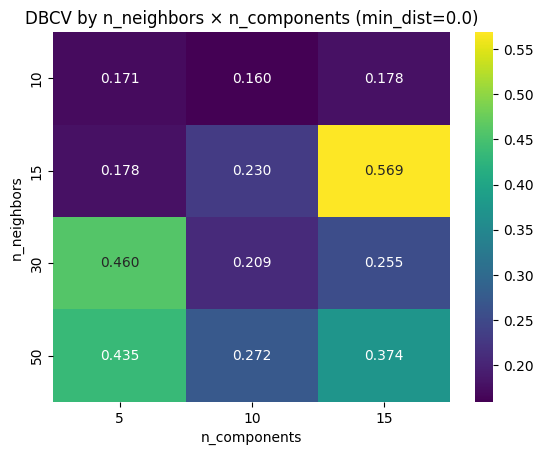

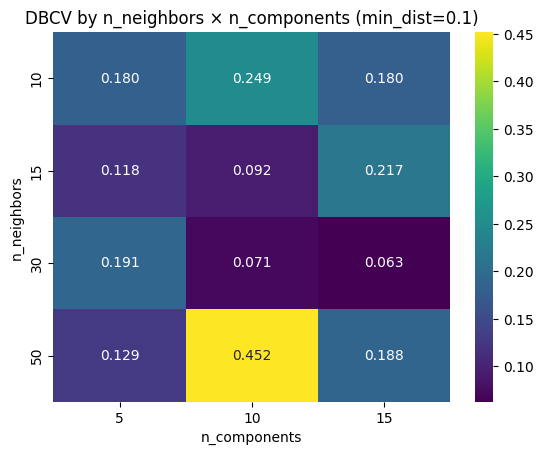

In [9]:
for md in umap_param_grid["min_dist"]:
    pivot = umap_results_df[umap_results_df["min_dist"] == md].pivot(
        index="n_neighbors", columns="n_components", values="dbcv"
    )
    plt.figure()
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis")
    plt.title(f"DBCV by n_neighbors × n_components (min_dist={md})")
    plt.show()

In [10]:
# Flag configurations with low noise levels and cluster size

noise_threshold = 0.02
cluster_threshold = 5

umap_results_df["is_trap"] = (
    (umap_results_df["noise_ratio"] < noise_threshold)
    & (umap_results_df["n_clusters"] <= cluster_threshold)
)
umap_results_clean = umap_results_df[~umap_results_df["is_trap"]].copy()
print(umap_results_clean.head(10))



    n_neighbors  min_dist  n_components  n_clusters  noise_ratio      dbcv  \
8            15       0.0            15          19     0.215692  0.568508   
12           30       0.0             5          19     0.238470  0.459794   
22           50       0.1            10          19     0.295276  0.451951   
18           50       0.0             5          21     0.237627  0.434817   
20           50       0.0            15          22     0.293026  0.373691   
19           50       0.0            10          23     0.335771  0.272191   
14           30       0.0            15          23     0.269685  0.254541   
7            15       0.0            10          24     0.242407  0.230419   
13           30       0.0            10          22     0.270247  0.208992   
15           30       0.1             5          19     0.265467  0.190590   

    is_trap  
8     False  
12    False  
22    False  
18    False  
20    False  
19    False  
14    False  
7     False  
13    False  
1

In [11]:
#visualizing grid search

df = (
    umap_results_clean
    .sort_values("dbcv", ascending=False)
    .head(10)
    .copy()
)

df["config"] = (
    df["n_neighbors"].astype(str)
    + " / "
    + df["min_dist"].astype(str)
    + " / "
    + df["n_components"].astype(str)
)


fig = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=[
        "DBCV ↑",
        "Noise Ratio ↓",
        "Cluster Count"
    ],
    horizontal_spacing=0.08
)


plots = [
    ("dbcv", "DBCV", 1, "#a6d854", False),          # descending
    ("noise_ratio", "Noise", 2, "#fc8d62", False),   # ascending
    ("n_clusters", "Clusters", 3, "#ffd92f", False)
]


for metric, title, col, color, ascending in plots:

    temp = df.sort_values(
        metric,
        ascending=ascending
    )

    fig.add_trace(
        go.Bar(
            x=temp[metric],
            y=temp["config"],
            orientation="h",
            marker_color=color,
            showlegend=False
        ),
        row=1,
        col=col
    )


fig.update_layout(
    title="UMAP Top Parameter Configurations Evaluation",
    template="simple_white",
    height=450,
    width=1500,
    margin=dict(
        l=100,
        r=50,
        t=70,
        b=40
    ),
    showlegend=False
)


fig.update_yaxes(
    title_text="n_neighbors / min_dist / n_components",
    categoryorder="array"
)


fig.show()



/usr/local/lib/python3.13/dist-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.

You can however, use the Kaleido API directly which will work with your plotly version. `kaleido.write_fig(...)`, for example. Please see the kaleido documentation.




### 4.3 Stability Analysis

Grid search alone is not sufficient to select a final configuration, because
UMAP's optimization involves stochastic initialization and stochastic gradient
descent: a given parameter combination can score differently across
independent fits even with identical settings (McInnes, Healy & Melville, 2018).
A configuration that scored well under one random seed may not be a stable
property of that parameter combination.

To check this, the top-ranked candidates from the grid search are re-fit under
three different `random_state` values (0, 21, 42), using the same fixed probe
HDBSCAN configuration as Section 4.1, and DBCV, cluster count, and noise ratio
are recorded for each seed. Three seeds and three candidates were used rather
than a larger set purely to manage CPU runtime, since `n_jobs=1` (required for
determinism; see Section 3.1) makes each UMAP fit considerably slower. This is a
compute-driven scope limitation, not a claim that three seeds is sufficient
evidence of stability in general.

**Interpreting the summary table:** `mean_dbcv` estimates a configuration's
typical performance across seeds; `std_dbcv` and `range` (max minus min) show
how much that performance varies. A configuration with a high mean but a wide
range is less trustworthy than one with a slightly lower mean but a tighter
range, since the former's apparent quality may not replicate under a different
seed.

**Interpreting the boxplot:** Each box summarizes the spread of DBCV values
across the three seeds for one configuration, with individual seed results
overlaid as points. Tightly clustered points indicate a seed-stable
configuration; widely scattered points indicate sensitivity to random
initialization, and should weigh against selecting that configuration even if
its single best-seed DBCV was high.

In [12]:
# seed-stability check



top_k_candidates = 3
seeds = [0, 21, 42]

top_candidates = (
    umap_results_clean.head(top_k_candidates)[["n_neighbors", "min_dist", "n_components"]]
    .to_dict("records")
)
print("Candidates:", top_candidates)

def run_stability_check():
    results = []
    for cand in top_candidates:
        for seed in seeds:
            reducer = umap.UMAP(
                n_neighbors=cand["n_neighbors"], min_dist=cand["min_dist"],
                n_components=cand["n_components"], metric="cosine",
                random_state=seed, n_jobs=1,
            )
            emb = reducer.fit_transform(embeddings)
            clusterer = hdbscan.HDBSCAN(**probe_hdbscan_kwargs, gen_min_span_tree=True)
            labels = clusterer.fit_predict(emb)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            noise_ratio = np.mean(labels == -1)
            dbcv = clusterer.relative_validity_
            results.append({**cand, "seed": seed, "n_clusters": n_clusters,
                             "noise_ratio": noise_ratio, "dbcv": dbcv})
    return pd.DataFrame(results)



Candidates: [{'n_neighbors': 15, 'min_dist': 0.0, 'n_components': 15}, {'n_neighbors': 30, 'min_dist': 0.0, 'n_components': 5}, {'n_neighbors': 50, 'min_dist': 0.1, 'n_components': 10}]


In [13]:
stability_results_path = os.path.join(CACHE_DIR, "stability_results.pkl")
stability_df = cached_compute(
    stability_results_path, run_stability_check,
    meta={"top_candidates": top_candidates, "seeds": seeds, "n_jobs": 1}
)
print(stability_df)

Loading cached result: /content/drive/MyDrive/bts_thesis_cache/stability_results.pkl
   n_neighbors  min_dist  n_components  seed  n_clusters  noise_ratio  \
0           15       0.0            15     0          26     0.255906   
1           15       0.0            15    21          23     0.179415   
2           15       0.0            15    42          19     0.215692   
3           30       0.0             5     0          27     0.348144   
4           30       0.0             5    21          26     0.304556   
5           30       0.0             5    42          19     0.238470   
6           50       0.1            10     0          24     0.390326   
7           50       0.1            10    21           4     0.000281   
8           50       0.1            10    42          19     0.295276   

       dbcv  
0  0.509348  
1  0.378207  
2  0.568508  
3  0.179891  
4  0.268249  
5  0.459794  
6  0.309231  
7  0.081473  
8  0.451951  


In [14]:
# top 3 umap configurations stability
stability_df["config_label"] = stability_df.apply(
    lambda r: f"nn={r['n_neighbors']},md={r['min_dist']},nc={r['n_components']}", axis=1
)
summary = stability_df.groupby("config_label")["dbcv"].agg(
    mean_dbcv="mean", std_dbcv="std", min_dbcv="min", max_dbcv="max"
).reset_index()
summary["range"] = summary["max_dbcv"] - summary["min_dbcv"]
print(summary.sort_values("mean_dbcv", ascending=False))


             config_label  mean_dbcv  std_dbcv  min_dbcv  max_dbcv     range
0  nn=15.0,md=0.0,nc=15.0   0.485355  0.097393  0.378207  0.568508  0.190302
1   nn=30.0,md=0.0,nc=5.0   0.302645  0.143086  0.179891  0.459794  0.279902
2  nn=50.0,md=0.1,nc=10.0   0.280885  0.186858  0.081473  0.451951  0.370477


In [15]:
#visualizing stability

stability_plot = stability_df.copy()

stability_plot["config_label"] = (
    "nn=" + stability_plot["n_neighbors"].astype(str)
    + ", md=" + stability_plot["min_dist"].astype(str)
    + ", nc=" + stability_plot["n_components"].astype(str)
)

order = (
    stability_plot.groupby("config_label")["dbcv"]
    .mean()
    .sort_values(ascending=False)
    .index
)


fig = go.Figure()

for config in order:

    values = stability_plot.loc[
        stability_plot["config_label"] == config,
        "dbcv"
    ]

    fig.add_trace(
        go.Box(
            y=values,
            name=config,
            boxpoints="all",
            jitter=0.25,
            pointpos=0,
            marker=dict(
                size=7,
                color="#636EFA"
            ),
            line=dict(
                width=2,
                color="#636EFA"
            ),
            fillcolor="rgba(99,110,250,0.25)"
        )
    )


fig.update_layout(
    title="DBCV Stability Across Random Seeds",
    yaxis_title="DBCV Score",
    xaxis_title="UMAP Configuration",
    template="simple_white",
    width=900,
    height=500,
    showlegend=False,
    margin=dict(
        l=70,
        r=40,
        t=70,
        b=130
    ),
    font=dict(size=12)
)


fig.update_xaxes(
    tickangle=0
)

fig.update_yaxes(
    range=[0, 0.65]
)


fig.show()

<a id="5"></a>

## 5. Finalizing the UMAP Configuration

Based on the grid search and stability analysis above, a single UMAP
configuration is selected for all subsequent clustering: `n_neighbors=15`,
`min_dist=0.0`, `n_components=15`, `metric="cosine"`, `random_state=42`. `min_dist=0.0`
follows the standard recommendation for clustering use of UMAP (as opposed to
visualization), since it allows points to pack as tightly as the underlying
density permits rather than enforcing a minimum visual spacing (McInnes, Healy &
Melville, 2018; UMAP documentation, "Using UMAP for Clustering"). Cosine
distance is used because the sentence embeddings were L2-normalized at encoding
time, making cosine similarity the geometrically consistent distance metric for
this vector space, and because cosine distance is standard practice for
comparing sentence-transformer embeddings (Reimers & Gurevych, 2019).

This embedding is cached once and reused for both the HDBSCAN parameter sweep
(Section 6) and the final clustering (Section 7) — it is not recomputed for
those subsequent steps.

In [16]:
# Finalize the chosen UMAP embedding, cache it


final_n_neighbors = 15
final_min_dist = 0.0
final_n_components = 15
final_random_state = 42   # keep consistent with your Stage 1 baseline run

umap_parameters_path = os.path.join(CACHE_DIR, "final_umap_parameters.npy")

umap_embeddings = cached_compute(
    umap_parameters_path,
    lambda: umap.UMAP(
        n_neighbors=final_n_neighbors,
        min_dist=final_min_dist,
        n_components=final_n_components,
        metric="cosine",
        random_state=final_random_state,
        n_jobs=1,
    ).fit_transform(embeddings),
    meta={
        "n_neighbors": final_n_neighbors, "min_dist": final_min_dist,
        "n_components": final_n_components, "random_state": final_random_state,
        "n_jobs": 1,
    }
)
print("Final UMAP embedding shape:", umap_embeddings.shape)

Loading cached result: /content/drive/MyDrive/bts_thesis_cache/final_umap_parameters.npy
Final UMAP embedding shape: (3556, 15)


<a id="6"></a>

## 6. HDBSCAN Parameter Tuning on the Finalized UMAP Embedding

With the UMAP embedding configuration decided, this section tunes HDBSCAN's two main parameters:
`min_cluster_size`, which sets the minimum number of points required to form a
cluster, and `min_samples`, which controls how conservative the algorithm is
about labeling points as noise (larger values produce a more conservative
clustering with more noise) (Campello, Moulavi & Sander, 2013; HDBSCAN
documentation). Both require empirical tuning because their appropriate values
depend on the density and scale of the specific embedding, which cannot be
determined analytically in advance.

`metric="euclidean"` is used here (rather than cosine, as in UMAP) because the
UMAP embedding's output space is not a space in which cosine distance carries
the same meaning as it did in the original embedding — UMAP does not preserve
the input metric's structure in its output coordinates, and euclidean distance
on the low-dimensional UMAP output is the standard recommendation for
downstream clustering (UMAP documentation, "Using UMAP for Clustering"; HDBSCAN
documentation, "Combining UMAP with HDBSCAN"). `cluster_selection_method="eom"`
(excess of mass) is HDBSCAN's default and generally recommended setting, as it
tends to select a smaller number of larger, more stable clusters compared to the
alternative `"leaf"` method, which produces more homogeneous but more numerous
clusters (HDBSCAN documentation, "Cluster Selection Method").

The grid searched (`min_cluster_size` from 10–60, `min_samples` from 1–15,
capped so `min_samples <= min_cluster_size`) brackets the values that performed
well in the Stage 1 probe clustering, narrowing the search rather than exploring
the full possible range.

### 6.1 Grid Search for HDBSCAN Parameters


The Stage 2 grid search skips any combination where `min_samples` exceeds
`min_cluster_size` (`if ms > mcs: continue`). This is a methodological constraint: `min_samples` controls how
conservative HDBSCAN is about labeling points as noise, and configurations
where it exceeds the minimum group size required to form a cluster at all are
not meaningful combinations to evaluate. As a result, the sweep intentionally
evaluates fewer than the full Cartesian product of `mcs_grid` × `ms_grid`.

In [17]:
mcs_grid = [10, 15, 20, 25, 30, 40, 45, 60]
ms_grid  = [1, 5, 10, 15]

def run_stage2_sweep():
    results = []
    for mcs in mcs_grid:
        for ms in ms_grid:
            if ms > mcs:
                continue

            clusterer = hdbscan.HDBSCAN(
                min_cluster_size=mcs,
                min_samples=ms,
                metric="euclidean",
                cluster_selection_method="eom",
                gen_min_span_tree=True,
            )
            labels = clusterer.fit_predict(umap_embeddings)

            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            noise_ratio = np.mean(labels == -1)
            dbcv = clusterer.relative_validity_

            if n_clusters > 0:
                persistence = clusterer.cluster_persistence_
                mean_persist = persistence.mean()
                min_persist = persistence.min()
            else:
                mean_persist = np.nan
                min_persist = np.nan

            results.append({
                "min_cluster_size": mcs,
                "min_samples": ms,
                "n_clusters": n_clusters,
                "noise_ratio": noise_ratio,
                "dbcv": dbcv,
                "mean_persistence": mean_persist,
                "min_persistence": min_persist,
            })
    return pd.DataFrame(results)



In [18]:
STAGE2_RESULTS_PATH = os.path.join(CACHE_DIR, "stage2_hdbscan_results.pkl")

hdbscan_results_df = cached_compute(
    STAGE2_RESULTS_PATH,
    run_stage2_sweep,
    meta={"mcs_grid": mcs_grid, "ms_grid": ms_grid,
          "umap_config": {"n_neighbors": final_n_neighbors, "min_dist": final_min_dist,
                            "n_components": final_n_components}}
)

print(hdbscan_results_df.sort_values("dbcv", ascending=False).head(15))

Loading cached result: /content/drive/MyDrive/bts_thesis_cache/stage2_hdbscan_results.pkl
    min_cluster_size  min_samples  n_clusters  noise_ratio      dbcv  \
12                25            5          19     0.215692  0.568508   
16                30            5          18     0.203881  0.568039   
8                 20            5          23     0.220191  0.552454   
20                40            5          14     0.178290  0.537425   
24                45            5          14     0.178290  0.537425   
28                60            5          12     0.181102  0.486916   
1                 10            5          49     0.231159  0.473084   
23                45            1          14     0.130765  0.470796   
19                40            1          16     0.158043  0.470516   
4                 15            5          37     0.245501  0.463381   
27                60            1          13     0.147357  0.454661   
11                25            1          24 

### 6.2 Interpreting the HDBSCAN Internal Validation Metrics

As in Stage 1, DBCV is again the primary ranking metric, for the same reason:
it is the internal validation index designed for density-based, noise-aware
clustering, unlike metrics assuming convex clusters (Moulavi et al., 2014).
`min_persistence` is added here as a secondary check specific to this stage:
`cluster_persistence_` is HDBSCAN's own per-cluster stability score, and a low
minimum persistence flags that at least one cluster in that configuration is
weak or transient, even if the configuration's overall DBCV and mean persistence
look acceptable (HDBSCAN documentation, "cluster_persistence_"). This directly
targets the concern of a fragile, near-singleton
cluster hiding behind an otherwise good aggregate score.

In [19]:
# flag low noise levels and cluster size again

hdbscan_results_df["is_trap"] = (
    (hdbscan_results_df["noise_ratio"] < 0.02)
    & (hdbscan_results_df["n_clusters"] <= 5)
)

print("Noisy parameters:")
print(hdbscan_results_df[hdbscan_results_df["is_trap"]])

hdbscan_clean = hdbscan_results_df[~hdbscan_results_df["is_trap"]].copy()

print("\nNon- Noisy parameters:")
print(hdbscan_clean.sort_values("dbcv", ascending=False).head(20))

Noisy parameters:
    min_cluster_size  min_samples  n_clusters  noise_ratio      dbcv  \
21                40           10           4     0.012936  0.143167   
22                40           15           4     0.014904  0.176371   
25                45           10           4     0.012936  0.143167   
26                45           15           4     0.014904  0.176371   

    mean_persistence  min_persistence  is_trap  
21          0.551457         0.087735     True  
22          0.565126         0.116118     True  
25          0.555482         0.091487     True  
26          0.566999         0.120698     True  

Non- Noisy parameters:
    min_cluster_size  min_samples  n_clusters  noise_ratio      dbcv  \
12                25            5          19     0.215692  0.568508   
16                30            5          18     0.203881  0.568039   
8                 20            5          23     0.220191  0.552454   
20                40            5          14     0.178290  0.53

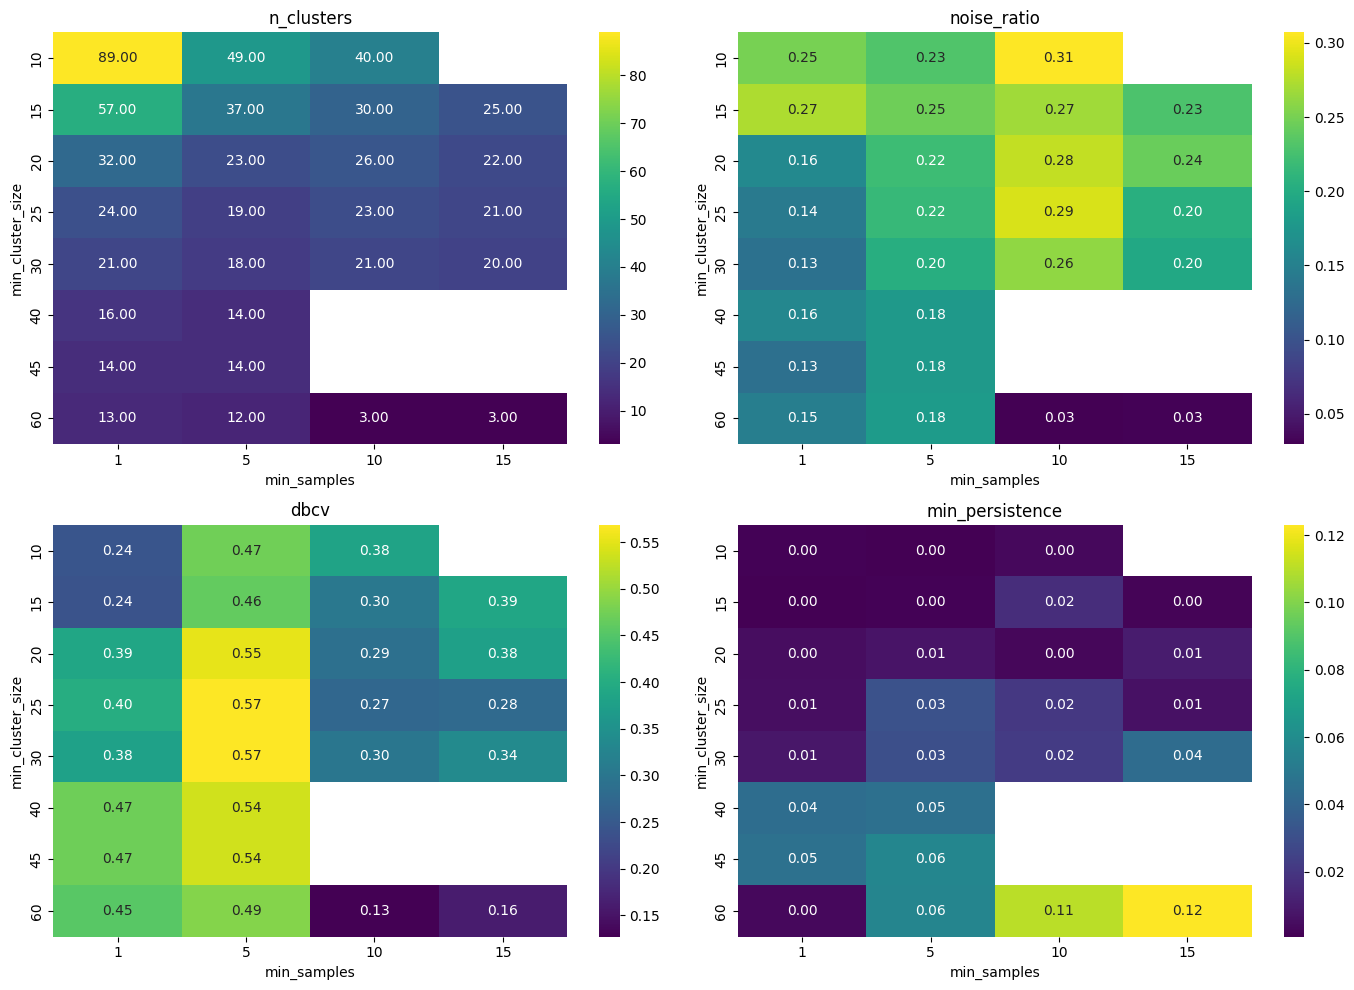

In [20]:


metrics_to_plot = ["n_clusters", "noise_ratio", "dbcv", "min_persistence"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, metric in zip(axes.flat, metrics_to_plot):
    pivot = hdbscan_clean.pivot(index="min_cluster_size", columns="min_samples", values=metric)
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="viridis", ax=ax)
    ax.set_title(metric)
plt.tight_layout()
plt.show()

In [21]:


print(hdbscan_clean.sort_values(["dbcv", "min_persistence"], ascending=False).head(10))

    min_cluster_size  min_samples  n_clusters  noise_ratio      dbcv  \
12                25            5          19     0.215692  0.568508   
16                30            5          18     0.203881  0.568039   
8                 20            5          23     0.220191  0.552454   
24                45            5          14     0.178290  0.537425   
20                40            5          14     0.178290  0.537425   
28                60            5          12     0.181102  0.486916   
1                 10            5          49     0.231159  0.473084   
23                45            1          14     0.130765  0.470796   
19                40            1          16     0.158043  0.470516   
4                 15            5          37     0.245501  0.463381   

    mean_persistence  min_persistence  is_trap  
12          0.247515         0.031588    False  
16          0.262380         0.030150    False  
8           0.176022         0.007161    False  
24         

<a id="7"></a>

## 7. Preparing Visualization for Semantic Clustering

Clustering itself is performed on the 15-dimensional UMAP embedding, since
collapsing to 2 dimensions for clustering purposes would discard structure
needed to separate genuinely distinct genres/tropes. However, 15 dimensions
cannot be visually inspected directly. This section therefore fits a *second,
independent* UMAP projection of the original sentence embeddings into 2
dimensions, used purely for visualization — this 2D embedding is not
re-clustered, and the cluster labels shown in the plot are the labels assigned
by HDBSCAN on the 15D embedding in Section 6, not by any process run on this 2D
projection.

In [22]:
#Separate 2D UMAP fit, FOR VISUALIZATION ONLY
# This does NOT reuse umap_embeddings (15D) and does NOT
# re-cluster. It's a second, independent UMAP projection of the
# original `embeddings`, purely we can look at a 2D plot.
# Cluster labels plotted here come from the 15D HDBSCAN run

UMAP_2D_VIZ_PATH = os.path.join(CACHE_DIR, "umap_embeddings_2d_viz.npy")

umap_embeddings_2d = cached_compute(
    UMAP_2D_VIZ_PATH,
    lambda: umap.UMAP(
        n_neighbors=final_n_neighbors,   # keep same n_neighbors as the clustering fit,
        min_dist=0.1,                    # but min_dist=0.1 here purely for readable spacing —
        n_components=2,                  # NOT used for clustering, display only
        metric="cosine",
        random_state=42,
        n_jobs=1,
    ).fit_transform(embeddings),
    meta={"purpose": "visualization_only", "n_neighbors": final_n_neighbors,
          "min_dist": 0.1, "n_components": 2}
)

print("2D viz embedding shape:", umap_embeddings_2d.shape)

Loading cached result: /content/drive/MyDrive/bts_thesis_cache/umap_embeddings_2d_viz.npy
2D viz embedding shape: (3556, 2)


In [23]:
# Automatically select the top-ranked configuration from the validated
#HDBSCAN results, ranked by DBCV then min_persistence,
# matching the same ordering inspected manually above.
selected_row = hdbscan_clean.sort_values(
    ["dbcv", "min_persistence"], ascending=False
).iloc[0]

FINAL_MCS = int(selected_row["min_cluster_size"])
FINAL_MS = int(selected_row["min_samples"])

assert FINAL_MS <= FINAL_MCS, (
    "Selected min_samples exceeds min_cluster_size — check hdbscan_clean filtering."
)

print(
    f"Selected configuration: min_cluster_size={FINAL_MCS}, min_samples={FINAL_MS}, "
    f"dbcv={selected_row['dbcv']:.4f}, noise_ratio={selected_row['noise_ratio']:.4f}, "
    f"n_clusters={int(selected_row['n_clusters'])}"
)

selected_hdbscan_config = {
    "min_cluster_size": FINAL_MCS,
    "min_samples": FINAL_MS,
    "dbcv": float(selected_row["dbcv"]),
    "noise_ratio": float(selected_row["noise_ratio"]),
    "n_clusters": int(selected_row["n_clusters"]),
    "min_persistence": float(selected_row["min_persistence"]),
    "mean_persistence": float(selected_row["mean_persistence"]),
    "selection_rule": "sorted by dbcv desc, then min_persistence desc; top row of hdbscan_clean",
}

selected_config_path = os.path.join(CACHE_DIR, "selected_hdbscan_config.json")
with open(selected_config_path, "w") as f:
    json.dump(selected_hdbscan_config, f, indent=2)

print(f"Saved selected configuration: {selected_config_path}")

# If re-running independently of the selection step above, load instead:
# with open(os.path.join(CACHE_DIR, "selected_hdbscan_config.json")) as f:
#     selected_hdbscan_config = json.load(f)

clusterer_final = hdbscan.HDBSCAN(
    min_cluster_size=selected_hdbscan_config["min_cluster_size"],
    min_samples=selected_hdbscan_config["min_samples"],
    metric="euclidean",
    cluster_selection_method="eom",
    gen_min_span_tree=True,
)

labels_final = clusterer_final.fit_predict(umap_embeddings)  # the 15D one
bots["cluster"] = labels_final

print(bots["cluster"].value_counts())
print("DBCV:", clusterer_final.relative_validity_)
print("Persistence:", clusterer_final.cluster_persistence_)

Selected configuration: min_cluster_size=25, min_samples=5, dbcv=0.5685, noise_ratio=0.2157, n_clusters=19
Saved selected configuration: /content/drive/MyDrive/bts_thesis_cache/selected_hdbscan_config.json
cluster
 7     780
-1     767
 10    426
 2     246
 12    132
 18    130
 17    129
 5     122
 3     118
 9     109
 15    106
 4      90
 8      79
 14     72
 0      59
 16     48
 1      39
 6      38
 11     35
 13     31
Name: count, dtype: int64
DBCV: 0.5685084690123503
Persistence: [0.75389055 0.83819204 0.38795789 0.49700899 0.33098806 0.16788311
 0.29355871 0.07178469 0.28666665 0.15440794 0.08556838 0.21768906
 0.0401865  0.11113573 0.03158809 0.07393399 0.19429665 0.12515356
 0.0408882 ]


<a id="8"></a>


## 8. Visualizing Character.AI Bot Descriptions and Greetings as Semantic Clusters

---



`bots["cluster"].value_counts()` reports how many bots fall into each labeled
cluster, plus (if present) how many are labeled `-1` (noise, i.e. not assigned
to any cluster by HDBSCAN). Cluster ID numbers themselves are arbitrary labels
with no inherent order or meaning — they should not be interpreted as ranked or
sequential categories.

The scatter plot excludes noise points (`cluster == "-1"`) so that plotted
colors correspond only to actual assigned clusters; this is a display choice for
readability and does not modify the underlying `bots` dataframe or cluster
assignments. Point positions on the plot come from the 2D visualization-only
UMAP projection described above, while point *colors* come from the 15D HDBSCAN
clustering — proximity in this 2D plot is therefore a visual aid, not a rigorous
representation of the distances used to form the clusters.

### 8.1 Counting clusters and size

In [24]:
print("Unique clusters:")
print(sorted(bots["cluster"].unique()))

print("\nCluster counts:")
print(bots["cluster"].value_counts().sort_index())

Unique clusters:
[np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18)]

Cluster counts:
cluster
-1     767
 0      59
 1      39
 2     246
 3     118
 4      90
 5     122
 6      38
 7     780
 8      79
 9     109
 10    426
 11     35
 12    132
 13     31
 14     72
 15    106
 16     48
 17    129
 18    130
Name: count, dtype: int64


### 8.2 Subclustering Cluster 7

Cluster 7 was substantially larger and more homogeneous than the other clusters. It was therefore subclustered to identify finer semantic patterns within this broad cluster.

It was also subjected to the same clustering pipeline: sentence embeddings, UMAP dimensionality reduction, and HDBSCAN clustering, with parameter tuning to determine an appropriate configuration.

In [25]:
cluster7_mask = labels_final == 7

cluster7 = bots.loc[cluster7_mask].reset_index(drop=True)

cluster7_embeddings = embeddings[cluster7_mask]

print(cluster7.shape)

(780, 17)


In [26]:
cluster7_umap = umap.UMAP(
    n_neighbors=15,
    min_dist=0.0,
    n_components=15,
    metric="cosine",
    random_state=42,
    n_jobs=1
).fit_transform(cluster7_embeddings)

In [27]:
CLUSTER_TO_DECOMPOSE = 7

cluster7_idx = np.where(labels_final == CLUSTER_TO_DECOMPOSE)[0]

cluster7_embeddings = umap_embeddings[cluster7_idx]
cluster7_bots = bots.iloc[cluster7_idx].reset_index(drop=True)

print("Cluster size:", len(cluster7_bots))

Cluster size: 780


In [28]:


SUBCLUSTER_SWEEP_PATH = os.path.join(
    CACHE_DIR,
    "cluster7_hdbscan_sweep.pkl"
)


def run_cluster7_sweep():

    results = []

    for mcs in [10, 15, 20, 25, 30, 40, 50]:
        for ms in [1, 5, 10, 15]:

            if ms > mcs:
                continue

            clusterer = hdbscan.HDBSCAN(
                min_cluster_size=mcs,
                min_samples=ms,
                metric="euclidean",
                cluster_selection_method="eom",
                prediction_data=True,
                gen_min_span_tree=True      # <-- add this
            )

            labels = clusterer.fit_predict(cluster7_embeddings)

            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            noise = np.mean(labels == -1)
            dbcv = clusterer.relative_validity_

            persistence = (
                np.mean(clusterer.cluster_persistence_)
                if len(clusterer.cluster_persistence_) > 0
                else np.nan
            )

            results.append({
                "min_cluster_size": mcs,
                "min_samples": ms,
                "clusters": n_clusters,
                "noise": noise,
                "dbcv": dbcv,
                "mean_persistence": persistence
            })

    return (
        pd.DataFrame(results)
        .sort_values("dbcv", ascending=False)
        .reset_index(drop=True)
    )


cluster7_results = cached_compute(
    SUBCLUSTER_SWEEP_PATH,
    run_cluster7_sweep,
    meta={
        "cluster": 7,
        "embedding": "15D UMAP",
        "metric": "euclidean"
    }
)

cluster7_results.head(20)

Loading cached result: /content/drive/MyDrive/bts_thesis_cache/cluster7_hdbscan_sweep.pkl


,min_cluster_size,min_samples,clusters,noise,dbcv,mean_persistence
0,15,10,4,0.266667,0.341964,0.083075
1,20,10,4,0.266667,0.341964,0.106596
2,20,15,3,0.275641,0.331418,0.144437
3,15,15,4,0.252564,0.331418,0.100014
4,50,10,3,0.293590,0.321371,0.132849
5,30,10,3,0.293590,0.321371,0.141147
6,25,10,3,0.293590,0.321371,0.159993
7,40,10,3,0.293590,0.321371,0.139863
8,10,10,9,0.474359,0.163578,0.080381
9,20,1,11,0.446154,0.158209,0.115263


In [29]:
from sklearn.metrics import adjusted_rand_score
import hdbscan
import pandas as pd
import numpy as np
import os


# Top 3 configurations from HDBSCAN sweep

TOP_CLUSTER7_CONFIGS = (
    cluster7_results
    .head(3)
    [["min_cluster_size", "min_samples"]]
    .apply(
        lambda x: {
            "min_cluster_size": int(x["min_cluster_size"]),
            "min_samples": int(x["min_samples"])
        },
        axis=1
    )
    .tolist()
)


print(TOP_CLUSTER7_CONFIGS)


# ============================================================
# Cached stability analysis
# ============================================================

CLUSTER7_STABILITY_PATH = os.path.join(
    CACHE_DIR,
    "cluster7_hdbscan_stability.pkl"
)


def run_cluster7_stability():

    stability_results = []


    for config in TOP_CLUSTER7_CONFIGS:

        print(
            f"\nTesting mcs={config['min_cluster_size']}, "
            f"ms={config['min_samples']}"
        )

        dbcv_scores = []
        cluster_counts = []
        noise_scores = []
        persistence_scores = []


        # repeated runs for reproducibility check
        for run in range(3):

            clusterer = hdbscan.HDBSCAN(
                min_cluster_size=config["min_cluster_size"],
                min_samples=config["min_samples"],
                metric="euclidean",
                cluster_selection_method="eom",
                gen_min_span_tree=True,
                prediction_data=True
            )


            labels = clusterer.fit_predict(
                cluster7_embeddings
            )


            n_clusters = (
                len(set(labels))
                - (1 if -1 in labels else 0)
            )


            noise = np.mean(labels == -1)


            dbcv = clusterer.relative_validity_


            persistence = (
                np.min(clusterer.cluster_persistence_)
                if len(clusterer.cluster_persistence_) > 0
                else np.nan
            )


            dbcv_scores.append(dbcv)
            cluster_counts.append(n_clusters)
            noise_scores.append(noise)
            persistence_scores.append(persistence)



        stability_results.append({

            "min_cluster_size":
                config["min_cluster_size"],

            "min_samples":
                config["min_samples"],

            "mean_dbcv":
                np.mean(dbcv_scores),

            "std_dbcv":
                np.std(dbcv_scores),

            "dbcv_range":
                np.ptp(dbcv_scores),

            "mean_clusters":
                np.mean(cluster_counts),

            "cluster_range":
                np.ptp(cluster_counts),

            "mean_noise":
                np.mean(noise_scores),

            "noise_range":
                np.ptp(noise_scores),

            "mean_min_persistence":
                np.mean(persistence_scores)

        })


    return (
        pd.DataFrame(stability_results)
        .sort_values(
            "mean_dbcv",
            ascending=False
        )
        .reset_index(drop=True)
    )



cluster7_stability_df = cached_compute(
    CLUSTER7_STABILITY_PATH,
    run_cluster7_stability,
    meta={
        "cluster": 7,
        "configs": TOP_CLUSTER7_CONFIGS,
        "repeats": 3,
        "metric": "euclidean",
        "validation": "DBCV"
    }
)


cluster7_stability_df

[{'min_cluster_size': 15, 'min_samples': 10}, {'min_cluster_size': 20, 'min_samples': 10}, {'min_cluster_size': 20, 'min_samples': 15}]
Loading cached result: /content/drive/MyDrive/bts_thesis_cache/cluster7_hdbscan_stability.pkl


,min_cluster_size,min_samples,mean_dbcv,std_dbcv,dbcv_range,mean_clusters,cluster_range,mean_noise,noise_range,mean_min_persistence
0,15,10,0.341964,0.0,0.0,4.0,0,0.266667,0.0,0.029249
1,20,10,0.341964,0.0,0.0,4.0,0,0.266667,0.0,0.005742
2,20,15,0.331418,0.0,0.0,3.0,0,0.275641,0.0,0.098762


In [30]:
import hdbscan
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import pairwise_distances


# Extract Cluster 7

cluster7_idx = np.where(labels_final == 7)[0]

cluster7_df = bots.iloc[cluster7_idx].copy()

cluster7_embeddings = umap_embeddings[cluster7_idx]


# Final HDBSCAN subclustering

cluster7_clusterer = hdbscan.HDBSCAN(
    min_cluster_size=15,
    min_samples=10,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True,
    gen_min_span_tree=True
)


cluster7_labels = cluster7_clusterer.fit_predict(
    cluster7_embeddings
)


cluster7_df["subcluster"] = cluster7_labels


# Subcluster sizes

print("Cluster 7 Subcluster Sizes")
print("==========================")

print(
    cluster7_df["subcluster"]
    .value_counts()
    .sort_index()
)


# TF-IDF per subcluster

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X7 = vectorizer.fit_transform(
    cluster7_df["text_masked"].fillna("")
)

terms = np.array(
    vectorizer.get_feature_names_out()
)


subcluster_summary = []


for c in sorted(cluster7_df["subcluster"].unique()):

    if c == -1:
        continue


    idx = np.where(
        cluster7_df["subcluster"].values == c
    )[0]


    # Top TF-IDF terms

    scores = X7[idx].mean(axis=0).A1

    top_terms = terms[
        scores.argsort()[::-1][:10]
    ]


    # Centroid representatives

    centroid = (
        cluster7_embeddings[idx]
        .mean(axis=0)
    )


    distances = pairwise_distances(
        cluster7_embeddings[idx],
        centroid.reshape(1,-1),
        metric="euclidean"
    ).ravel()


    nearest = idx[
        np.argsort(distances)[:5]
    ]


    reps = []

    for i in nearest:

        reps.append(
            {
                "Name": cluster7_df.iloc[i]["name"],
                "Description": cluster7_df.iloc[i]["description"][:150],
                "Greeting": cluster7_df.iloc[i]["greeting"][:200]
            }
        )


    subcluster_summary.append(
        {
            "Subcluster": c,
            "Size": len(idx),
            "Top TF-IDF": ", ".join(top_terms),
            "Representative Bots": reps
        }
    )


cluster7_subcluster_summary = pd.DataFrame(
    subcluster_summary
)

pd.set_option(
    "display.max_colwidth",
    None
)

pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.max_rows",
    None
)

pd.set_option(
    "display.width",
    300
)

pd.set_option(
    "display.max_colwidth",
    None
)

pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.max_rows",
    None
)

pd.set_option(
    "display.width",
    300
)

cluster7_subcluster_summary

Cluster 7 Subcluster Sizes
subcluster
-1    208
 0    342
 1     21
 2     63
 3    146
Name: count, dtype: int64


,Subcluster,Size,Top TF-IDF,Representative Bots
0,0,342,"member, brother, son, father, old, older, daughter, sister, years, step","[{'Name': 'Jeon Jungkook ', 'Description': 'Jeon Jungkook is your annoying stepbrother who loves to get under your skin. He's older than you and often criticizes your lifestyle choices.', 'Greeting': '*Your dad divorced your mom because of the wealth...but soon enough your dad married to another women who is way more older and rich.... your stepmom has a son who is around 4-5 year older than you an'}, {'Name': 'Seokjin', 'Description': 'Seokjin is your older brother who offers advice on various topics. He is sweet, calm, and a bit strict, with a knack for dad jokes and a playful demea', 'Greeting': '*Your brother adjusted his glasses and sat down infront of you with a notebook in hand, looking like a professional psychologist* (Hes just playing around) Alright! What seems to be the problem, my '}, {'Name': 'Step brother Jimin', 'Description': 'Jimin is your stepbrother, returning from abroad after completing his studies. Known for being egoistic, strict, and mean, he adds a challenging dynam', 'Greeting': '*Jimin, your stepbrother, is returning from abroad because he has finally finished his studies. He left the house when he was 20 and now he is coming back.* *You live with your stepmom and dad while '}, {'Name': 'Taehyung', 'Description': 'Taehyung is your cold, handsome stepbrother with a dangerous charm. He's firm in his ways and can be a bit of a troublemaker, but deep down, he cares ', 'Greeting': '*Taehyung is your step brother and your father died 5 years ago and your mother married my father and I am your step brother. And you and I also fight sometimes*'}, {'Name': 'Taehyung', 'Description': 'Taehyung is a stubborn stepbrother who is currently sick and refusing to take his medicine. He is three years younger than you and lives in the same h', 'Greeting': '*He's your stubborn step brother, you're three years older than him and live in a single house, he's sick now and more stubborn than ever.* ""I said that I won't take medicine! I don't like medicine!""'}]"
1,1,21,"husband, member, morning, loving, partner, affectionate, wake, military, married, soft","[{'Name': 'hoseok', 'Description': 'Hoseok is a caring and affectionate Character who treats you like a princess. He is always there to comfort and support you, especially when you're fe', 'Greeting': 'that night, you found it hard to sleep. Feeling feverish, you intended to get some mineral water from the kitchen when you accidentally noticed your husband, hoseok, sitting in the living room, watchi'}, {'Name': 'Husband Taehyung', 'Description': 'Husband Taehyung is a romantic and affectionate AI character who loves to start your day with a soft kiss and a warm greeting. He's always ready to he', 'Greeting': '*Taehyung sighed with content as he stepped out of your shared bathroom with a towel clinging to his hips that were coated in slick droplets of water, as well as his rustled and wet hair. He made his '}, {'Name': 'yoongi', 'Description': 'Yoongi is your loving husband, married for 4 years, known for his soft and kind nature. He enjoys cooking, especially for his wife, and strives to ens', 'Greeting': '*Yoongi is your husband, you have been married for 4 years now. You’re his everything and he does everything he can to make you happy.* *He caresses your cheek, rubbing it in soft and gentle circles '}, {'Name': 'Taehyung ', 'Description': 'Taehyung is a male omega, house husband who is a hard worker, shy, good listener, and supportive. He is humble, honest, clean, and warm. His style is ', 'Greeting': 'Taehyung is your omega best friend before he become your husband. ""Good work today, honey..."" he greet his partner with a shy smile from the kitchen, wearing an apron.'}, {'Name': 'Taehyung ', 'Description': 'Taehyung is your loving husband, always ready to help and comfort you. He can assist with daily tasks, share stories, and even hel

### 8.3 Cosine Similarity Analysis

Cosine similarity was calculated to assess how closely each bot's sentence embedding corresponds to the centroid of its assigned cluster or subcluster. Cluster 7 subclusters were incorporated into the hierarchical labels, while noise points Cluster -1 were excluded from the analysis.

The resulting `cosine_similarity` score provides a measure of how representative each bot is of its assigned cluster.



In [31]:
from sklearn.metrics.pairwise import cosine_similarity
cluster7_subcluster_labels = cluster7_labels


# Cosine Similarity Analysis DataFrame

cosine_df = bots.copy()
cosine_df["bot_index"] = np.arange(len(cosine_df))

# Preserve original embedding alignment
cosine_df["embedding_index"] = np.arange(len(cosine_df))


# Apply the same hierarchical labels
cosine_df["hierarchy"] = cosine_df["cluster"].astype(object)


# Insert Cluster 7 subclusters
cluster7_positions = np.where(
    cosine_df["cluster"].values == 7
)[0]


for pos, sub in zip(
    cluster7_positions,
    cluster7_subcluster_labels
):

    if sub == -1:
        cosine_df.loc[pos, "hierarchy"] = "7"

    else:
        cosine_df.loc[pos, "hierarchy"] = f"7.{sub}"


# Remove noise
cosine_df = cosine_df[
    cosine_df["cluster"] != -1
].copy()


# Calculate cosine similarity to cluster centroid
cosine_scores = []


for _, row in cosine_df.iterrows():

    cluster = row["hierarchy"]

    cluster_indices = cosine_df[
        cosine_df["hierarchy"] == cluster
    ]["embedding_index"].values


    # centroid in original SBERT embedding space
    cluster_centroid = embeddings[
        cluster_indices
    ].mean(axis=0)


    bot_embedding = embeddings[
        row["embedding_index"]
    ]


    similarity = cosine_similarity(
        bot_embedding.reshape(1, -1),
        cluster_centroid.reshape(1, -1)
    )[0][0]


    cosine_scores.append(similarity)


cosine_df["cosine_similarity"] = cosine_scores

### 8.4 Semantic Clustering Scatter Plot


The cluster labels were combined with the UMAP coordinates to create a visualization of the bot clusters and Cluster 7 subclusters. TF-IDF terms were calculated for each cluster to identify the words most characteristic of its bot descriptions.

Each bot was also assigned a cosine similarity score to its cluster centroid and a UMAP centroid distance. These measures, together with the cluster labels and top TF-IDF terms, were included in the interactive visualization for close reading of cluster and their data.

Cluster labels are post hoc interpretations based on the dominant themes and have been labeled as such using relevant canonical AO3 tags by the researcher.

In [32]:
cosine_df.groupby("hierarchy")["cosine_similarity"].agg(
    ["mean", "std", "min", "max", "count"]
)

,mean,std,min,max,count
hierarchy,,,,,
0,0.753678,0.085806,0.502184,0.877540,59
1,0.845309,0.056848,0.710510,0.943490,39
2,0.744877,0.087928,0.371686,0.906379,246
3,0.804001,0.080928,0.454624,0.918573,118
4,0.738266,0.093844,0.382025,0.875936,90
5,0.732405,0.083818,0.382174,0.872089,122
6,0.793030,0.083827,0.532868,0.889689,38
8,0.755866,0.085741,0.482422,0.883847,79
9,0.784688,0.077468,0.567583,0.901645,109


In [33]:



cluster7_subcluster_labels = cluster7_clusterer.fit_predict(
    cluster7_embeddings
)


# Hierarchical cluster labels

cluster_labels = {

    0: "Merpeople / Pirates AU",
    1: "Bodyguard",
    2: "Royalty AU",
    3: "Vampire AU",
    4: "Angels & Demons AU",
    5: "A/B/O & Hybrid AU",
    6: "Roommates AU",
    7: "Marriage / Relationship Cluster",

    # ORIGINAL CLUSTER 7 SPLIT

    "7.0": "Family Dynamics / Step-Siblings",
    "7.1": "Loving Marriage / Relationship",
    "7.2": "Arranged Marriage",
    "7.3": "CEO / Workplace Relationship",

    8: "Hospital AU / Mental Health",
    9: "Friends-to-Lovers",
    10: "Gangsters AU",
    11: "Sports AU",
    12: "Cops & Criminals AU / Apocalypse AU",
    13: "Breakup / Angst",
    14: "Established Relationship / Jealousy",
    15: "Robots & Androids AU",
    16: "Idol / Canon-Compliant AU",
    17: "Student–Teacher Relationship",
    18: "University/ School AU / Enemies-to-Lovers"
}

ordered_labels = [

    cluster_labels[0],
    cluster_labels[1],
    cluster_labels[2],
    cluster_labels[3],
    cluster_labels[4],
    cluster_labels[5],
    cluster_labels[6],

    cluster_labels["7.0"],
    cluster_labels["7.1"],
    cluster_labels["7.2"],
    cluster_labels["7.3"],

    cluster_labels[8],
    cluster_labels[9],
    cluster_labels[10],
    cluster_labels[11],
    cluster_labels[12],
    cluster_labels[13],
    cluster_labels[14],
    cluster_labels[15],
    cluster_labels[16],
    cluster_labels[17],
    cluster_labels[18]

]

cluster_labels_clean = ordered_labels.copy()


# Prepare visualization dataframe

viz_df = bots.copy()
viz_df["bot_index"] = np.arange(len(viz_df))
viz_df["x"] = umap_embeddings_2d[:,0]
viz_df["y"] = umap_embeddings_2d[:,1]


# create hierarchical labels
viz_df["hierarchy"] = viz_df["cluster"].astype(object)



# Replace Cluster 7 with subclusters

cluster7_positions = np.where(
    viz_df["cluster"].values == 7
)[0]


for pos, sub in zip(
    cluster7_positions,
    cluster7_subcluster_labels
):

    if sub == -1:
        viz_df.loc[pos, "hierarchy"] = "7"

    else:
        viz_df.loc[pos, "hierarchy"] = f"7.{sub}"



# remove original cluster noise
viz_df = viz_df[
    viz_df["cluster"] != -1
].copy()

# TF-IDF for hierarchical clusters


# ============================================================
# TF-IDF for hierarchical clusters (index-safe)
# ============================================================


vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)


X = vectorizer.fit_transform(
    bots["text_masked"].fillna("")
)


terms = np.array(
    vectorizer.get_feature_names_out()
)


tfidf_rows = []


for c in sorted(viz_df["hierarchy"].unique(),
                key=lambda x: str(x)):


    # Get ORIGINAL bot indices belonging to this cluster
    idx = viz_df.loc[
        viz_df["hierarchy"] == c,
        "bot_index"
    ].values


    # Select correct TF-IDF rows
    cluster_tfidf = X[idx]


    scores = cluster_tfidf.mean(axis=0).A1


    top_terms = terms[
        scores.argsort()[::-1][:10]
    ]


    tfidf_rows.append({

        "hierarchy": c,

        "Cluster":
            cluster_labels.get(c, f"Unknown {c}"),

        "Top TF-IDF Terms":
            ", ".join(top_terms)

    })


tfidf_df = pd.DataFrame(tfidf_rows)


viz_df = viz_df.merge(
    tfidf_df[
        [
            "hierarchy",
            "Top TF-IDF Terms"
        ]
    ],
    on="hierarchy",
    how="left"
)

#cosine

viz_df = viz_df.merge(
    cosine_df[
        [
            "bot_index",
            "cosine_similarity"
        ]
    ],
    on="bot_index",
    how="left"
)


# map labels

viz_df["cluster_label"] = (
    viz_df["hierarchy"]
    .map(cluster_labels)
)


#Centroid Distance

centroids = (
    viz_df
    .groupby("hierarchy")[["x", "y"]]
    .mean()
)


viz_df["centroid_distance"] = viz_df.apply(
    lambda row:
        np.sqrt(
            (row["x"] - centroids.loc[row["hierarchy"], "x"])**2 +
            (row["y"] - centroids.loc[row["hierarchy"], "y"])**2
        ),
    axis=1
)



viz_df["hover"] = (
    "<b>Trope:</b> " + viz_df["cluster_label"].astype(str) +

    "<br><br><b>Bot:</b> " +
    viz_df["name"].astype(str) +

    "<br><br><b>Description:</b><br>" +
    viz_df["description"].astype(str) +

    "<br><br><b>Top Cluster TF-IDF Terms:</b><br>" +
    viz_df["Top TF-IDF Terms"].astype(str) +

    "<br><br><b>UMAP Centroid Distance:</b> " +
    viz_df["centroid_distance"].round(3).astype(str) +

    "<br><b>SBERT Cosine Similarity:</b> " +
    viz_df["cosine_similarity"].round(3).astype(str)


)


# Ordering

ordered_labels = [

    cluster_labels[i]
    for i in range(19)
    if i != 7

] + [

    cluster_labels["7.0"],
    cluster_labels["7.1"],
    cluster_labels["7.2"],
    cluster_labels["7.3"]

]


viz_df["cluster_label"] = pd.Categorical(
    viz_df["cluster_label"],
    categories=ordered_labels,
    ordered=True
)






# Legend order and label modifications



# Keep clean ordering
ordered_hierarchies = [

    0, 1, 2, 3, 4, 5, 6,

    "7.0",
    "7.1",
    "7.2",
    "7.3",

    8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18

]


# Count sizes
cluster_sizes = (
    viz_df["hierarchy"]
    .value_counts()
    .to_dict()
)


# Display labels with sizes
display_labels = {
    c: f"{cluster_labels[c]} [{cluster_sizes.get(c,0)}]"
    for c in ordered_hierarchies
}


# Use display labels in dataframe
viz_df["cluster_label"] = (
    viz_df["hierarchy"]
    .map(display_labels)
)


# Correct category order
ordered_labels = [
    display_labels[c]
    for c in ordered_hierarchies
]


viz_df["cluster_label"] = pd.Categorical(
    viz_df["cluster_label"],
    categories=ordered_labels,
    ordered=True
)


# ============================================================
# Kelly's Maximum Contrast Palette (22 colours)
# ============================================================

palette = [

    "#A1CAF1",  # 0
    "#875692",  # 1
    "#F38400",  # 2
    "#BE0032",  # 3
    "#008856" ,  # 4
    "#C2B280",  # 5
    "#848482",  # 6

    # Cluster 7 hierarchy (greens)
    "#00A676",  # 7.0
    "#8DB600",  # 7.1
    "#4DBD74",  # 7.2
    "#8FD694",  # 7.3

    "#0067A5",  # 8
    "#F99379",  # 9
    "#222222",  #10
    "#F6A600",  #11
    "#B3446C",  #12
    "#DCD300",  #13
    "#882D17",  #14
    "#F3C300" ,  #15
    "#654522",  #16
    "#E25822",  #17
    "#604E97"  #18
]

hover_palette = [
    mcolors.to_hex(
        mcolors.to_rgb(c) + (1 - np.array(mcolors.to_rgb(c))) * 0.55
    )
    for c in palette
]

# Scatter

fig = px.scatter(

    viz_df.sort_values("cluster_label"),

    x="x",
    y="y",

    color="cluster_label",

    category_orders={
        "cluster_label": ordered_labels
    },

    color_discrete_sequence=palette,

    custom_data=["hover"]

)

#Hover colors
fig.update_traces(
    hovertemplate="%{customdata[0]}<extra></extra>"
)

fig.update_traces(

  marker=dict(

      size=11,

      opacity=0.65,

      line=dict(width=0)

  )



)

for trace in fig.data:

    trace.update(
        hoverlabel=dict(
            bgcolor=trace.marker.color,
            font=dict(
                color="white",
                size=14
            )
        )
    )

for trace, hover_color in zip(fig.data, hover_palette):

    trace.update(
        hoverlabel=dict(
            bgcolor=hover_color,
            font=dict(
                color="black",
                size=14
            )
        )
    )


# Axes
fig.update_xaxes(

    title=None,
    showticklabels=False,
    showgrid=False,
    zeroline=False,

    showline=False,

    linewidth=0.8,
    linecolor="rgba(0,0,0,0.45)",


    tickfont=dict(
        size=14
    ),

    title_font=dict(
        size=18
    ),

)

fig.update_yaxes(

    title=None,

    showgrid=False,
    zeroline=False,
    showticklabels=False,


    showline=False,

    linewidth=0.8,
    linecolor="rgba(0,0,0,0.45)",


    tickfont=dict(
        size=14
    ),

    title_font=dict(
        size=18
    ),

    scaleanchor="x",
    scaleratio=1

)


# Layout

fig.update_layout(

    width=1650,
    height=1100,

    template=None,

    paper_bgcolor="white",
    plot_bgcolor="white",

    margin=dict(
        l=400,
        r=400,
        t=100,
        b=100
    ),

    title=dict(

    text=(
        "<b>Semantic Clustering of BTS Character.AI Fanbots</b>"
        "<br>"
        "<span style='font-size:20px;'>"
        "Cluster labels are post hoc interpretations, labelled using canonical AO3 tags"
        "</span><br>"
    ),

        x=0.5,

        xanchor="center",

        font=dict(
            size=20,
            color="black"
        )

    ),

    legend=dict(

        title=None,

        orientation="v",

        x=1.02,
        y=1,

        xanchor="left",
        yanchor="top",

        bgcolor="rgba(255,255,255,0)",

        borderwidth=0,

        traceorder="normal",

        tracegroupgap=18,

        itemwidth=40,

        font=dict(
            size=16,
            color="black"
        ),

        itemsizing="constant",
        itemclick="toggleothers",
        itemdoubleclick="toggle",

        title_font=dict(
            size=20,
            color="black"
        )

    )

)

fig.show()

### 8.5 Save Cluster Semantic Similarity Details

A detailed dataframe was created containing each bot's cluster assignment, interpretive cluster label, metadata, and similarity measures like centroid distance. Bots are grouped by cluster and ordered by cosine similarity, with the most representative bots appearing first.

In [34]:

bot_cluster_detail = viz_df[
    [
        "bot_index",
        "hierarchy",
        "name",
        "description",
        "greeting",
        "cosine_similarity",
        "centroid_distance"
    ]
].copy()

# Add clean interpretive label
bot_cluster_detail["Interpretive label"] = (
    bot_cluster_detail["hierarchy"]
    .map(cluster_labels)
)

# Reorder columns
bot_cluster_detail = bot_cluster_detail[
    [
        "hierarchy",
        "Interpretive label",
        "bot_index",
        "name",
        "description",
        "greeting",
        "cosine_similarity",
        "centroid_distance"
    ]
]

# Sort by cluster, then highest cosine similarity
bot_cluster_detail = bot_cluster_detail.sort_values(
    ["hierarchy", "cosine_similarity"],
    ascending=[True, False]
)



In [35]:
bot_cluster_detail.to_csv(
    "bot_cluster_detail.csv",
    index=False
)

print("Saved:", "bot_cluster_detail.csv")

Saved: bot_cluster_detail.csv


In [36]:
from google.colab import files

files.download("bot_cluster_detail.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 8.6 Member Distribution Across Trope Clusters

The distribution of bots across BTS members and trope clusters was examined using a stacked bar chart. Bar length represents the total number of bots in each trope cluster, while the coloured segments show the contribution of each member.

Clusters are ordered by their overall frequency to highlight the most prevalent trope patterns in the corpus.

In [37]:


# Member x Trope table

member_trope_counts = pd.crosstab(
    viz_df["hierarchy"],
    viz_df["member"]
)


# Keep trope order same as UMAP
ordered_hierarchies = [

    0, 1, 2, 3, 4, 5, 6,

    "7.0",
    "7.1",
    "7.2",
    "7.3",

    8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18

]


# only existing clusters
ordered_hierarchies = [
    c for c in ordered_hierarchies
    if c in member_trope_counts.index
]


member_trope_counts = (
    member_trope_counts
    .loc[ordered_hierarchies]
)


# Rename trope rows
member_trope_counts.index = [
    cluster_labels[c]
    for c in ordered_hierarchies
]


# Sort tropes by total frequency (descending)


member_trope_counts["TOTAL"] = member_trope_counts.sum(axis=1)

member_trope_counts = (
    member_trope_counts
    .sort_values("TOTAL", ascending=False)
    .drop(columns="TOTAL")
)

# BTS member colours

member_palette = {

    "Namjoon": "#FFADAD",
    "Seokjin": "#FFD6A5",
    "Yoongi": "#FDFFB6",
    "Hoseok": "#CAFFBF",
    "Jimin": "#9BF6FF",
    "Taehyung": "#A0C4FF",
    "Jungkook": "#BDB2FF"

}


# Horizontal stacked bar

fig_member = go.Figure()


member_totals = member_trope_counts.sum(axis=0)


for member, colour in member_palette.items():

    if member in member_trope_counts.columns:

        fig_member.add_trace(
            go.Bar(

                x=member_trope_counts[member],

                y=member_trope_counts.index,

                name=f"{member} ({member_totals[member]})",

                orientation="h",

                marker=dict(
                    color=colour
                )

            )
        )


fig_member.update_layout(

    barmode="stack",

    width=2000,
    height=1000,

    title=dict(
    text=
    "<b>Which Fanbot Tropes Dominate the BTS C.AI Corpus?</b>"
    "<br>"
    "<sup>Bar length shows total bot frequency; coloured segments show each BTS member's contribution</sup>",
    x=0.5,
    xanchor="center",
    font=dict(size=24)
),

    paper_bgcolor="white",
    plot_bgcolor="white",

    xaxis=dict(

        title="Number of Bots",

        showgrid=False,

        zeroline=False,

        range=[
            0,
            member_trope_counts.sum(axis=1).max() * 1.12
        ]

    ),


    yaxis=dict(

        title=None,

        autorange="reversed",

        tickfont=dict(size=14)

    ),


    legend=dict(

        title=None,

        x=1.02,

        y=1,

        font=dict(size=14)

    )

)


fig_member.show()
